# Week 4 - Gradient Descent

## Problem 1


### Given

In [ ]:
## Required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
## Black box gradient descent function

def black_box_gd(X_train, y_train, weights, bias, learning_rate):
  """
  This is your provided black-box function.
  It performs a single gradient descent update step.
  """
  n_samples = X_train.shape[0]

  # 1. Calculate predictions based on current weights and bias
  y_pred = X_train @ weights + bias

  # 2. Calculate the error
  error = y_pred - y_train

  # 3. Calculate gradients
  gradient_weights = (2 / n_samples) * X_train.T @ error
  gradient_bias = (2 / n_samples) * np.sum(error)

  # 4. Update parameters
  new_weights = weights - learning_rate * gradient_weights
  new_bias = bias - learning_rate * gradient_bias

  return new_weights, new_bias

### Data Generation

In [ ]:
# Set parameters for the dataset
N = 2000  # Number of samples
d = 10    # Number of features
np.random.seed(42) # for reproducibility

In [ ]:
# Generate features from a multivariate Gaussian distribution
X = np.random.multivariate_normal(mean=np.zeros(d), cov=np.eye(d), size=N)

In [ ]:
# Choose a true weight vector and bias
w_true = np.random.randn(d, 1)
b_true = np.array([[-2.5]]) # A scalar bias

In [ ]:
# Generate labels with additive Gaussian noise
noise = np.random.randn(N, 1) * 0.5 # Noise with standard deviation 0.5
y = X @ w_true + b_true + noise

### Data Splitting

In [ ]:
# Shuffling and splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
print(f"Training set shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing set shape:  X={X_test.shape}, y={y_test.shape}")

Training set shape: X=(1600, 10), y=(1600, 1)
Testing set shape:  X=(400, 10), y=(400, 1)


### Helper Functions

In [ ]:
def mean_squared_error(y_true, y_pred):
  """Calculates the Mean Squared Error loss."""
  return np.mean((y_pred - y_true)**2)

In [ ]:
def solver(X_train, y_train, X_test, y_test, eta, iterations):
  """
  The main solver that performs gradient descent and records the loss history.
  This part is kept manual to observe the effects of the learning rate.
  """
  m, d = X_train.shape
  w = np.zeros((d, 1))
  b = 0

  train_losses = []
  test_losses = []

  for i in range(iterations):
      # update the weights and biases using gradient descent black box
      w, b = black_box_gd(X_train, y_train, w, b, eta)

      # Record training and testing loss for this iteration
      train_losses.append(mean_squared_error(y_train, X_train @ w + b))
      test_losses.append(mean_squared_error(y_test, X_test @ w + b))

  return train_losses, test_losses

### Experimentation

In [ ]:
# Define learning rates and number of iterations
learning_rates = [0.0001, 0.001, 0.01, 0.1, 1]
max_iterations = 500

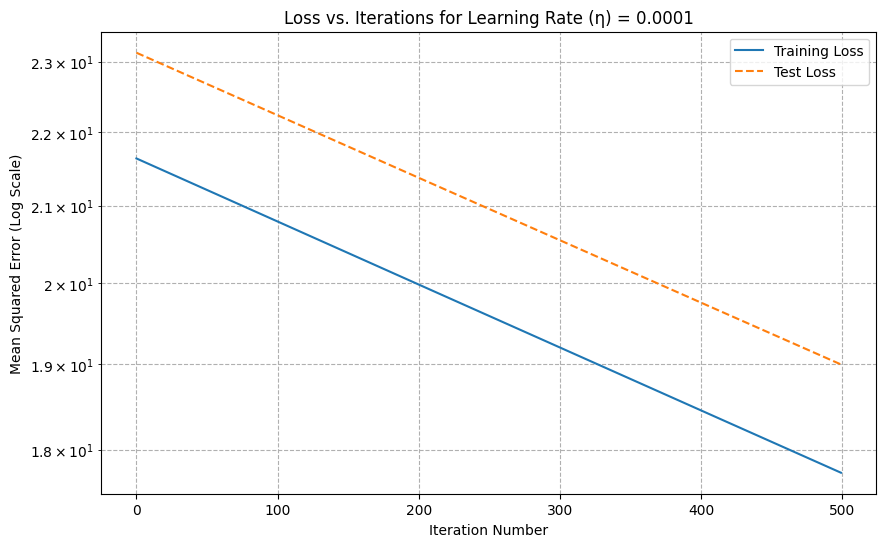

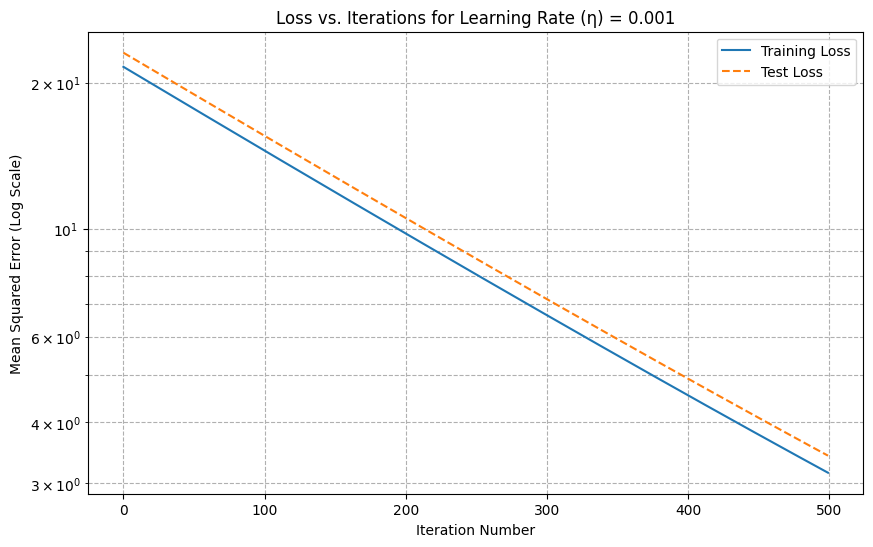

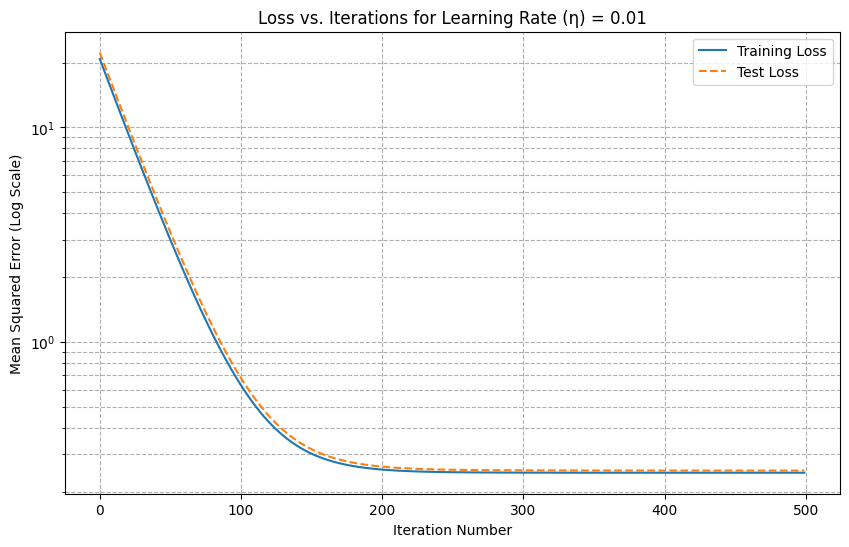

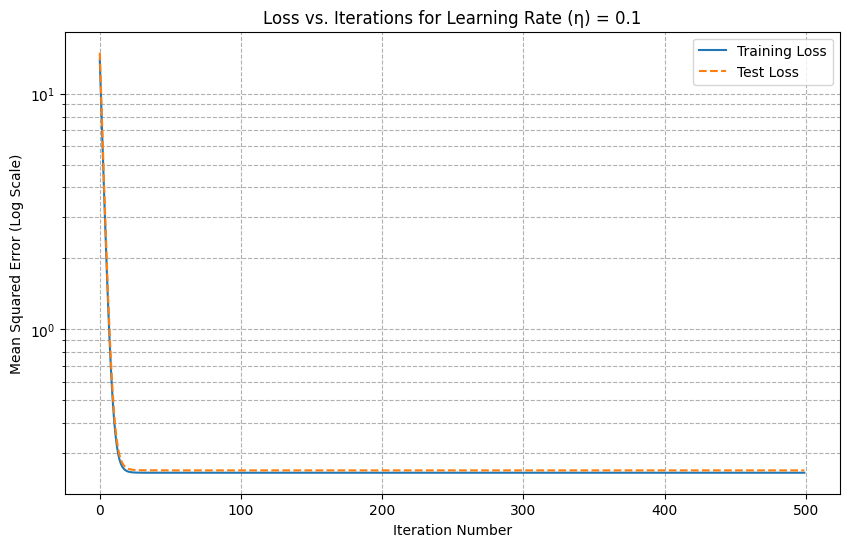

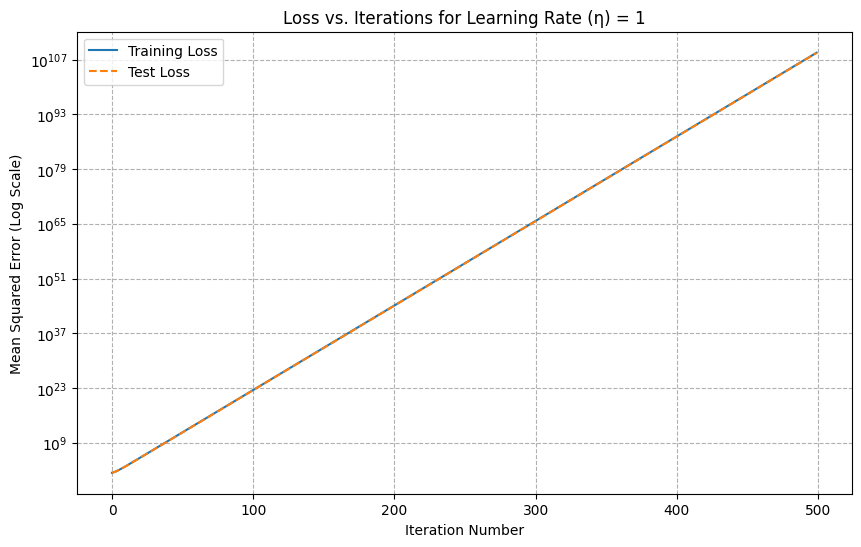

In [ ]:
# Run solver for each learning rate and plot the results
for eta in learning_rates:
    # Run the gradient descent solver
    train_loss_hist, test_loss_hist = solver(
        X_train, y_train, X_test, y_test, eta, max_iterations
    )

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(range(max_iterations), train_loss_hist, label='Training Loss')
    plt.plot(range(max_iterations), test_loss_hist, label='Test Loss', linestyle='--')

    # Use a log scale for the y-axis to better visualize large changes
    plt.yscale('log')

    plt.title(f'Loss vs. Iterations for Learning Rate (η) = {eta}')
    plt.xlabel('Iteration Number')
    plt.ylabel('Mean Squared Error (Log Scale)')
    plt.legend()
    plt.grid(True, which="both", ls="--")
    plt.show()